In [ ]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import random, joblib
from google.colab import drive

drive.mount('/content/drive')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Mounted at /content/drive
Using device: cuda


In [ ]:
BASE = '/content/drive/MyDrive/DNN_Dataset/Sequence_files/'

raw_train = np.load(BASE + 'sequences_rich_train.npy')
raw_test  = np.load(BASE + 'sequences_rich_test.npy')

print(f"raw_train: {raw_train.shape}")
print(f"raw_test:  {raw_test.shape}")

def extract_velocities(data):
    """
    Input:  (N, 11, 8)
    - features: x, y, w, h, drone_vx, drone_vy, drone_vz, altitude
    Output: (N, 10, 8)
    - features: dx, dy, w, h, drone_vx, drone_vy, drone_vz, altitude
    """
    vels = np.zeros_like(data)
    vels[:, 1:, 0] = data[:, 1:, 0] - data[:, :-1, 0]  # dx
    vels[:, 1:, 1] = data[:, 1:, 1] - data[:, :-1, 1]  # dy
    vels[:, :, 2:] = data[:, :, 2:]  # w, h + drone features
    return vels[:, 1:, :]  # drop first frame → (N, 10, 8)

# X = 10 frames of 8 features
X_train = extract_velocities(raw_train)  # (N, 10, 8)
X_test  = extract_velocities(raw_test)   # (N, 10, 8)

# Y = next frame velocity dx, dy, w, h
Y_train = np.zeros((raw_train.shape[0], 4))
Y_train[:, 0] = raw_train[:, 10, 0] - raw_train[:, 9, 0]
Y_train[:, 1] = raw_train[:, 10, 1] - raw_train[:, 9, 1]
Y_train[:, 2:] = raw_train[:, 10, 2:4]
Y_test = np.zeros((raw_test.shape[0], 4))
Y_test[:, 0] = raw_test[:, 10, 0] - raw_test[:, 9, 0]
Y_test[:, 1] = raw_test[:, 10, 1] - raw_test[:, 9, 1]
Y_test[:, 2:] = raw_test[:, 10, 2:4]

print(f"X_train: {X_train.shape} → Y_train: {Y_train.shape}")
print(f"X_test:  {X_test.shape}  → Y_test:  {Y_test.shape}")


raw_train: (141737, 11, 12)
raw_test:  (15749, 11, 12)
X_train: (141737, 10, 12) → Y_train: (141737, 4)
X_test:  (15749, 10, 12)  → Y_test:  (15749, 4)


In [ ]:
from sklearn.preprocessing import StandardScaler
import joblib

scaler_X = StandardScaler()
N_tr, seq_len, feats = X_train.shape

X_train_scaled = scaler_X.fit_transform(
    X_train.reshape(-1, feats)).reshape(N_tr, seq_len, feats)
X_test_scaled  = scaler_X.transform(
    X_test.reshape(-1, feats)).reshape(X_test.shape[0], seq_len, feats)

joblib.dump(scaler_X, BASE + 'scaler_X.pkl')

scaler_Y = StandardScaler()
Y_train_scaled = scaler_Y.fit_transform(Y_train)
Y_test_scaled  = scaler_Y.transform(Y_test)
joblib.dump(scaler_Y, BASE + 'scaler_Y.pkl')

print("Scaled ✓")
print(f"X_train_scaled: {X_train_scaled.shape}")


Scaled ✓
X_train_scaled: (141737, 10, 12)


In [ ]:
class SequenceDataset(Dataset):
    def __init__(self, X, Y, augment=False):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)
        self.augment = augment

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx].clone()
        y = self.Y[idx]
        if self.augment:
            x = x + torch.randn_like(x) * 0.02
            drop_prob = random.uniform(0.10, 0.15)
            for t in range(1, 10):
                if random.random() < drop_prob:
                    x[t] = x[t - 1]
        return x, y

train_dataset = SequenceDataset(X_train_scaled, Y_train_scaled, augment=True)
test_dataset  = SequenceDataset(X_test_scaled,  Y_test_scaled,  augment=False)

train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=512, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)} | Test batches: {len(test_loader)}")

Train batches: 277 | Test batches: 31


In [ ]:
class GRUTracker(nn.Module):
    def __init__(self, input_size=12, hidden_size=128, num_layers=2, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(input_size=input_size, hidden_size=hidden_size,
                          num_layers=num_layers, batch_first=True,
                          dropout=dropout if num_layers > 1 else 0.0)
        self.fc = nn.Linear(hidden_size, 4)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])

model = GRUTracker().to(DEVICE)
dummy = torch.zeros(8, 10, 12).to(DEVICE)
assert model(dummy).shape == (8, 4)
print("Model output shape: ✓")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Model output shape: ✓
Total parameters: 154,116


In [ ]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=3, factor=0.5)

EPOCHS    = 20
SAVE_PATH = BASE + 'best_gru.pth'

best_val_loss = float('inf')
train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        running_loss += loss.item() * len(xb)
    train_loss = running_loss / len(train_dataset)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            val_loss += criterion(model(xb), yb).item() * len(xb)
    val_loss /= len(test_dataset)
    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), SAVE_PATH)
        print(f"Epoch {epoch:2d} | train: {train_loss:.6f} | test: {val_loss:.6f}  ✓ saved")
    else:
        print(f"Epoch {epoch:2d} | train: {train_loss:.6f} | test: {val_loss:.6f}")

Epoch  1 | train: 0.100332 | test: 0.014016  ✓ saved
Epoch  2 | train: 0.026565 | test: 0.010189  ✓ saved
Epoch  3 | train: 0.020861 | test: 0.006353  ✓ saved
Epoch  4 | train: 0.018540 | test: 0.005483  ✓ saved
Epoch  5 | train: 0.017899 | test: 0.005365  ✓ saved
Epoch  6 | train: 0.017689 | test: 0.004975  ✓ saved
Epoch  7 | train: 0.017128 | test: 0.003929  ✓ saved
Epoch  8 | train: 0.017324 | test: 0.004726
Epoch  9 | train: 0.015673 | test: 0.005348
Epoch 10 | train: 0.016440 | test: 0.004391
Epoch 11 | train: 0.014753 | test: 0.003983
Epoch 12 | train: 0.015197 | test: 0.003037  ✓ saved
Epoch 13 | train: 0.019270 | test: 0.003989
Epoch 14 | train: 0.014403 | test: 0.002807  ✓ saved
Epoch 15 | train: 0.014351 | test: 0.003379
Epoch 16 | train: 0.013185 | test: 0.003412
Epoch 17 | train: 0.013516 | test: 0.003085
Epoch 18 | train: 0.015467 | test: 0.002276  ✓ saved
Epoch 19 | train: 0.014171 | test: 0.002681
Epoch 20 | train: 0.014565 | test: 0.002782


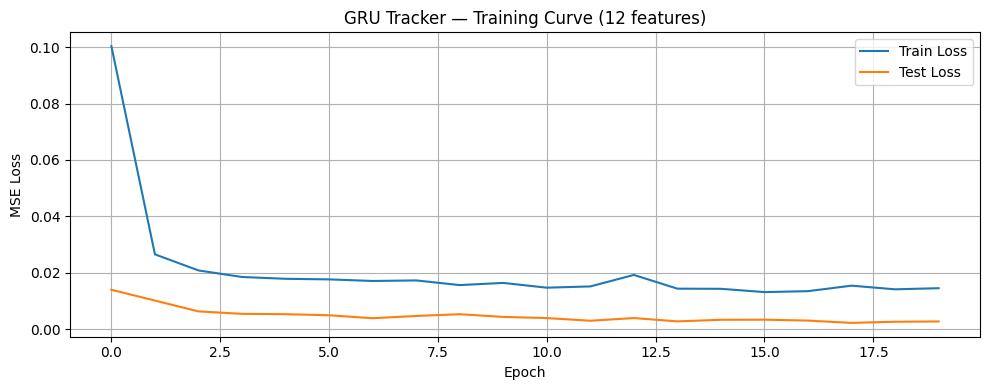

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses,   label='Test Loss')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('GRU Tracker — Training Curve (12 features)')
plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig(BASE + 'gru_loss_curve.png')
plt.show()

In [ ]:
class GRUMotionModel:
    def __init__(self, model_path, scaler_X, scaler_Y, device=None):
        self.device   = device or torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model    = GRUTracker().to(self.device)
        self.model.load_state_dict(torch.load(model_path, map_location=self.device))
        self.model.eval()
        self.scaler_X = scaler_X
        self.scaler_Y = scaler_Y

    def predict(self, history):
        while len(history) < 10:
            history = [history[0]] + history
        arr = np.array(history[-10:], dtype=np.float32)
        arr = self.scaler_X.transform(arr)
        seq = torch.tensor(arr, dtype=torch.float32).unsqueeze(0).to(self.device)
        with torch.no_grad():
            pred = self.model(seq).cpu().numpy()
        pred_unscaled = self.scaler_Y.inverse_transform(pred)
        return pred_unscaled[0].tolist()  # returns [dx, dy, w, h]

motion_model = GRUMotionModel(SAVE_PATH, scaler_X, scaler_Y)
print("GRUMotionModel loaded ✓")


GRUMotionModel loaded ✓


GRU Total Parameters: 154,116
Test Average IoU (1000 samples): 0.9612  (target: > 0.65)


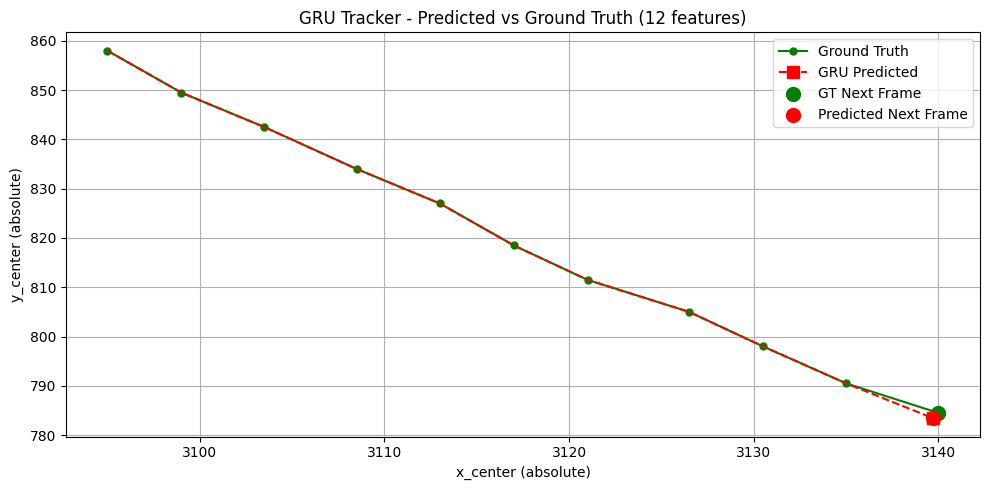


Ground Truth next box : [3092.0, 762.0, 96.0, 45.0]
Predicted next box    : [3091.9524, 761.9208, 95.5198, 43.0175]


In [ ]:
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()

def iou_1d(b1, b2):
    x1 = max(b1[0], b2[0])
    y1 = max(b1[1], b2[1])
    x2 = min(b1[0]+b1[2], b2[0]+b2[2])
    y2 = min(b1[1]+b1[3], b2[1]+b2[3])
    inter = max(0, x2-x1) * max(0, y2-y1)
    union = b1[2]*b1[3] + b2[2]*b2[3] - inter
    return inter / max(union, 1e-6)

# Compute Average IoU on test set (first 1000 samples for speed)
all_iou = []
for i in range(min(1000, len(raw_test))):
    sample = raw_test[i]
    input_hist = extract_velocities(sample[np.newaxis])[0]
    gt_box = sample[10, :4]
    pred_vel = motion_model.predict(input_hist.tolist())
    last_abs = sample[9, :4]
    pred_box = [last_abs[0] + pred_vel[0], last_abs[1] + pred_vel[1], pred_vel[2], pred_vel[3]]
    all_iou.append(iou_1d(pred_box, gt_box.tolist()))

print(f"GRU Total Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Test Average IoU (1000 samples): {np.mean(all_iou):.4f}  (target: > 0.65)")

# Trajectory
sample_raw     = raw_test[0]
input_history  = extract_velocities(sample_raw[np.newaxis])[0]
gt_next        = sample_raw[10, :4].tolist()
predicted_vel  = motion_model.predict(input_history.tolist())
last_abs       = sample_raw[9, :4].tolist()
predicted_next = [last_abs[0] + predicted_vel[0], last_abs[1] + predicted_vel[1], predicted_vel[2], predicted_vel[3]]

history_boxes  = [sample_raw[i, :4].tolist() for i in range(10)]

xs_gt   = [b[0]+b[2]/2 for b in history_boxes] + [gt_next[0]+gt_next[2]/2]
ys_gt   = [b[1]+b[3]/2 for b in history_boxes] + [gt_next[1]+gt_next[3]/2]
xs_pred = [b[0]+b[2]/2 for b in history_boxes] + [predicted_next[0]+predicted_next[2]/2]
ys_pred = [b[1]+b[3]/2 for b in history_boxes] + [predicted_next[1]+predicted_next[3]/2]

plt.figure(figsize=(10, 5))
plt.plot(xs_gt,   ys_gt,   'g-o',  label='Ground Truth',  markersize=5)
plt.plot(xs_pred, ys_pred, 'r--s', label='GRU Predicted', markersize=8, markevery=[-1])
plt.scatter(xs_gt[-1],        ys_gt[-1],        color='green', s=100, zorder=5, label='GT Next Frame')
plt.scatter(xs_pred[-1], ys_pred[-1], color='red',   s=100, zorder=5, label='Predicted Next Frame')
plt.xlabel('x_center (absolute)')
plt.ylabel('y_center (absolute)')
plt.title('GRU Tracker - Predicted vs Ground Truth (12 features)')
plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig(BASE + 'gru_trajectory.png')
plt.show()

print(f"\nGround Truth next box : {[round(v,4) for v in gt_next]}")
print(f"Predicted next box    : {[round(v,4) for v in predicted_next]}")


In [ ]:
print(f"raw_test sample frame: {raw_test[0, 0, :]}")
print(f"raw_test max x: {raw_test[:,:,0].max():.4f}")
print(f"raw_test min x: {raw_test[:,:,0].min():.4f}")

raw_test sample frame: [ 3.0490000e+03  8.3800000e+02  9.2000000e+01  4.0000000e+01
  4.7672791e+01  9.2695122e+00  4.3097897e+01  4.6200001e+01
  1.4689999e+02  9.8997345e+00  8.0997829e+00 -9.9997319e-02]
raw_test max x: 3816.0000
raw_test min x: 0.0000
